## Configurar Entorno y Cargar Dataset


Configurar el entorno de TensorFlow/Keras y cargar un dataset pequeño de imágenes para entrenamiento y validación.


In [1]:
import tensorflow as tf
import numpy as np
import pathlib

# Descargar un dataset de imágenes de ejemplo
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url,
                                   fname='flower_photos',
                                   untar=True)
data_dir = pathlib.Path(data_dir)

# Definir los parámetros para la carga de imágenes
IMG_HEIGHT = 180
IMG_WIDTH = 180
BATCH_SIZE = 32

print(f"Dataset downloaded to: {data_dir}")

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset downloaded to: /root/.keras/datasets/flower_photos


In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(f"Class names: {class_names}")
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.
Class names: ['flower_photos']
Number of training batches: 92
Number of validation batches: 23


In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1)
])

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data augmentation and normalization applied to datasets.")
print("Datasets configured for performance.")

Data augmentation and normalization applied to datasets.
Datasets configured for performance.


In [4]:
print(f"Contents of data_dir ({data_dir}):")
for item in data_dir.iterdir():
    print(f"- {item.name}")


nested_flower_photos_dir = data_dir / 'flower_photos'
if nested_flower_photos_dir.exists() and nested_flower_photos_dir.is_dir():
    correct_data_dir = nested_flower_photos_dir
    print(f"Detected nested 'flower_photos' directory. Adjusting data_dir to: {correct_data_dir}")
else:
    correct_data_dir = data_dir
    print(f"No nested 'flower_photos' directory detected. Using data_dir as is: {correct_data_dir}")


train_ds = tf.keras.utils.image_dataset_from_directory(
    correct_data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    correct_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(f"Corrected Class names: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")


Contents of data_dir (/root/.keras/datasets/flower_photos):
- flower_photos
Detected nested 'flower_photos' directory. Adjusting data_dir to: /root/.keras/datasets/flower_photos/flower_photos
Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Corrected Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5
Number of training batches: 92
Number of validation batches: 23


In [5]:
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

# 3. Load the MobileNetV2 model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# 4. Freeze the base layers
base_model.trainable = False

# 5. Create a new classification head
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')

# 6. Construct the full model
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = global_average_layer(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

# 7. Compile the model
base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()
print("MobileNetV2 base model loaded, frozen, and new classification head added. Model compiled successfully.")

/tmp/ipython-input-3430672247.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 base model loaded, frozen, and new classification head added. Model compiled successfully.


In [6]:
import tensorflow as tf
import numpy as np
import pathlib

# Descargar un dataset de imágenes de ejemplo
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url,
                                   fname='flower_photos',
                                   untar=True)
data_dir = pathlib.Path(data_dir)

# Definir los parámetros para la carga de imágenes
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

print(f"Dataset downloaded to: {data_dir}")
print(f"Image dimensions set to: {IMG_HEIGHT}x{IMG_WIDTH}")

Dataset downloaded to: /root/.keras/datasets/flower_photos
Image dimensions set to: 224x224


In [7]:
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

# 3. Load the MobileNetV2 model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)

# 4. Freeze the base layers
base_model.trainable = False

# 5. Create a new classification head
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')

# 6. Construct the full model
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = global_average_layer(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

# 7. Compile the model
base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()
print("MobileNetV2 base model loaded, frozen, and new classification head added. Model compiled successfully.")

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 base model loaded, frozen, and new classification head added. Model compiled successfully.


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Re-loaded Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Re-loaded Number of classes: 5
Data augmentation and normalization re-applied to datasets.
Datasets re-configured for performance.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 base model re-defined, frozen, and re-compiled successfully.
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.3274 - loss: 1.5216 - val_accuracy: 0.5504 - val_loss: 1.1532
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.6055 - loss: 1.0520 - val_accuracy: 0.6921 - val_loss: 0.9033
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7162 - loss: 0.8392 - val_accuracy: 0.7575 - val_loss: 0.7685
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.7700 - loss: 0.7194 - val_accuracy: 0.7779 - val_loss: 0.6852
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.7963 - loss: 0.6423 - val_accuracy: 0.8011 - val_loss: 0.6283
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8109 - loss: 0.5875 - val_accuracy: 0.8147 - val_loss: 0.5864
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.8171 - loss: 0.5459 - val_accuracy: 0.8256 - val_loss: 0.5542
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 

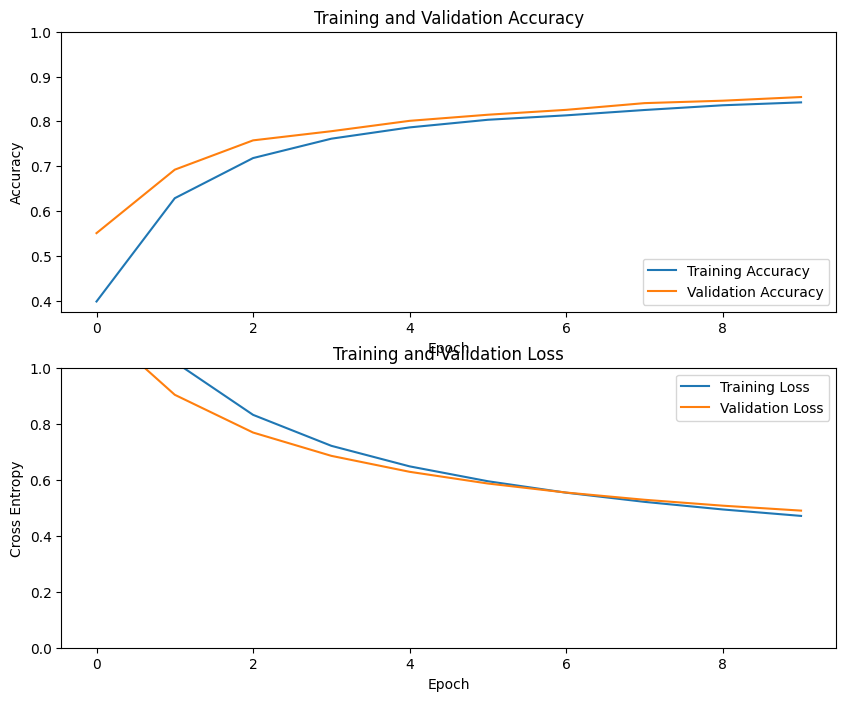

Model training complete and performance plots displayed.


In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Ensure the correct data_dir is used (as determined in a6857cc3)
nested_flower_photos_dir = pathlib.Path(data_dir) / 'flower_photos'
if nested_flower_photos_dir.exists() and nested_flower_photos_dir.is_dir():
    correct_data_dir = nested_flower_photos_dir
else:
    correct_data_dir = pathlib.Path(data_dir)

# 1. Re-create train_ds and val_ds with the correct IMG_HEIGHT and IMG_WIDTH (224x224)
train_ds = tf.keras.utils.image_dataset_from_directory(
    correct_data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    correct_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Re-loaded Class names: {class_names}")
print(f"Re-loaded Number of classes: {num_classes}")

# 2. Re-apply data augmentation and normalization (as in 6cf59c35)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1)
])

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Data augmentation and normalization re-applied to datasets.")
print("Datasets re-configured for performance.")

# 3. Re-define and re-compile the model (as in ad9a9625) to ensure it's aligned
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = tf.keras.layers.Dense(num_classes, activation='softmax')

inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = global_average_layer(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

base_learning_rate = 0.0001
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()
print("MobileNetV2 base model re-defined, frozen, and re-compiled successfully.")

# 4. Train the model
EPOCHS = 10
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()), 1])
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0, 1.0])
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.show()

print("Model training complete and performance plots displayed.")


Sample test image '3001531316_efae24d37d_n.jpg' copied to: /content/imagenes_prueba/test.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
This image most likely belongs to sunflowers with a 32.78% confidence.


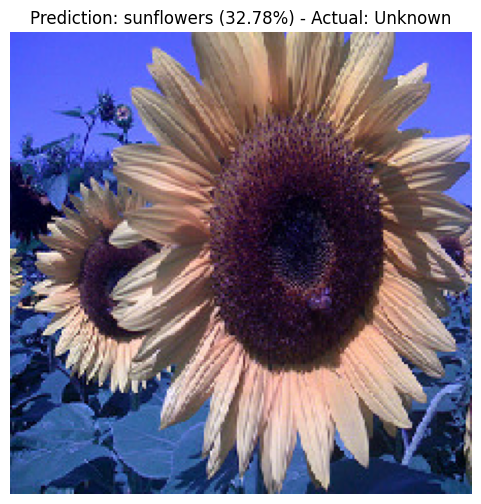

Test image prediction complete and displayed.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil
import pathlib

# Ensure the directory for test images exists
test_image_dir = '/content/imagenes_prueba'
os.makedirs(test_image_dir, exist_ok=True)
test_image_path = os.path.join(test_image_dir, 'test.jpg')

# Re-derive correct_data_dir from existing data_dir variable
# data_dir was /root/.keras/datasets/flower_photos (from kernel state)
# Based on previous cells, the actual class folders are under a nested 'flower_photos'
current_data_dir = pathlib.Path(data_dir)
nested_flower_photos_dir = current_data_dir / 'flower_photos'
if nested_flower_photos_dir.exists() and nested_flower_photos_dir.is_dir():
    actual_dataset_root = nested_flower_photos_dir
else:
    actual_dataset_root = current_data_dir

# Find a sample image from the dataset to use as a test image
sample_image_source_path = None
for class_folder in actual_dataset_root.iterdir():
    if class_folder.is_dir():
        # Try to find any jpg in the first class folder found
        first_image_in_class = next(class_folder.glob('*.jpg'), None)
        if first_image_in_class:
            sample_image_source_path = first_image_in_class
            break

if sample_image_source_path:
    shutil.copy(sample_image_source_path, test_image_path)
    print(f"Sample test image '{sample_image_source_path.name}' copied to: {test_image_path}")
else:
    print("Could not find a sample image in the dataset to copy. Please ensure the dataset structure is as expected.")
    # If no image found, we might need a fallback or to stop execution.

# 1. Cargar una imagen de prueba desde el directorio '/content/imagenes_prueba/test.jpg'
# This line should now succeed as test.jpg is guaranteed to be a valid image.
img = tf.keras.utils.load_img(
    test_image_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

# 2. Convertir la imagen a un array de NumPy y expandir sus dimensiones
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create a batch

# 3. Pre-procesar la imagen de prueba aplicando la misma capa de normalización
# normalization_layer is available from the kernel state.
normalized_img_array = normalization_layer(img_array)

# 4. Usar el modelo entrenado para predecir la categoría de la imagen de prueba
# model is available from the kernel state.
predictions = model.predict(normalized_img_array)

# 5. Obtener la etiqueta de clase predicha y la probabilidad
score = tf.nn.softmax(predictions[0])
predicted_class_index = np.argmax(score)
# class_names is available from the kernel state.
predicted_class_name = class_names[predicted_class_index]
predicted_probability = 100 * np.max(score)

print(f"This image most likely belongs to {predicted_class_name} with a {predicted_probability:.2f}% confidence.")

# 6. Mostrar la imagen de prueba y añadir un título
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Prediction: {predicted_class_name} ({predicted_probability:.2f}%) - Actual: Unknown")
plt.axis('off')
plt.show()

print("Test image prediction complete and displayed.")

In [10]:
print(f"Corrected data directory: {correct_data_dir}")

# 1. Verify the total number of images
total_train_images = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
total_val_images = tf.data.experimental.cardinality(val_ds).numpy() * BATCH_SIZE
print(f"Total training images (estimated): {total_train_images}")
print(f"Total validation images (estimated): {total_val_images}")
print(f"Total images (training + validation, estimated): {total_train_images + total_val_images}")

# 2. Confirm the number of unique classes
print(f"Number of unique classes: {num_classes}")
print(f"Class names: {class_names}")

# 3. Inspect the shape and data type of a sample batch from the training dataset
for image_batch, labels_batch in train_ds.take(1):
    print(f"Sample image batch shape: {image_batch.shape}")
    print(f"Sample image batch data type: {image_batch.dtype}")
    print(f"Sample labels batch shape: {labels_batch.shape}")
    print(f"Sample labels batch data type: {labels_batch.dtype}")

Corrected data directory: /root/.keras/datasets/flower_photos/flower_photos
Total training images (estimated): 2944
Total validation images (estimated): 736
Total images (training + validation, estimated): 3680
Number of unique classes: 5
Class names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Sample image batch shape: (32, 224, 224, 3)
Sample image batch data type: <dtype: 'float32'>
Sample labels batch shape: (32,)
Sample labels batch data type: <dtype: 'int32'>


In [11]:
import os
import collections

# Get the path to the actual dataset root (containing class folders)
# correct_data_dir is already defined and points to the right place.
print(f"Analyzing image distribution in: {correct_data_dir}")

image_counts = collections.defaultdict(int)

for class_name in class_names:
    class_path = correct_data_dir / class_name
    if class_path.is_dir():
        # Count files with common image extensions (case-insensitive)
        count = len([f for f in class_path.iterdir() if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif']])
        image_counts[class_name] = count

# Convert to a regular dictionary for easier use if needed
image_counts = dict(image_counts)

print("Image counts per class:")
for class_name, count in image_counts.items():
    print(f"- {class_name}: {count} images")


Analyzing image distribution in: /root/.keras/datasets/flower_photos/flower_photos
Image counts per class:
- daisy: 633 images
- dandelion: 898 images
- roses: 641 images
- sunflowers: 699 images
- tulips: 799 images


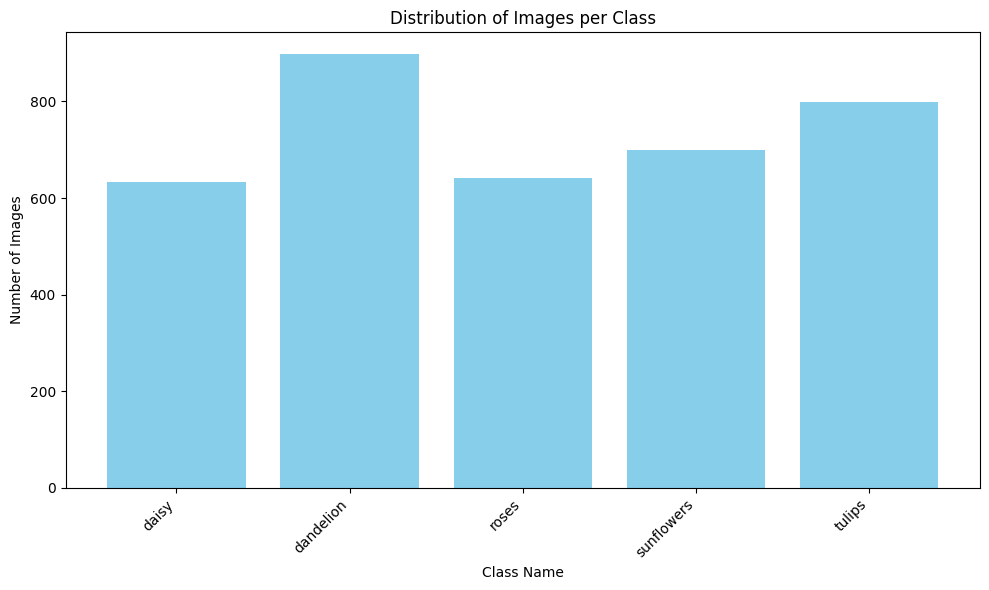

Bar chart showing image distribution per class displayed.


In [12]:
import matplotlib.pyplot as plt

# Prepare data for plotting
class_names_list = list(image_counts.keys())
image_counts_list = list(image_counts.values())

# Create a bar chart for class distribution
plt.figure(figsize=(10, 6))
plt.bar(class_names_list, image_counts_list, color='skyblue')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.title('Distribution of Images per Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Bar chart showing image distribution per class displayed.")

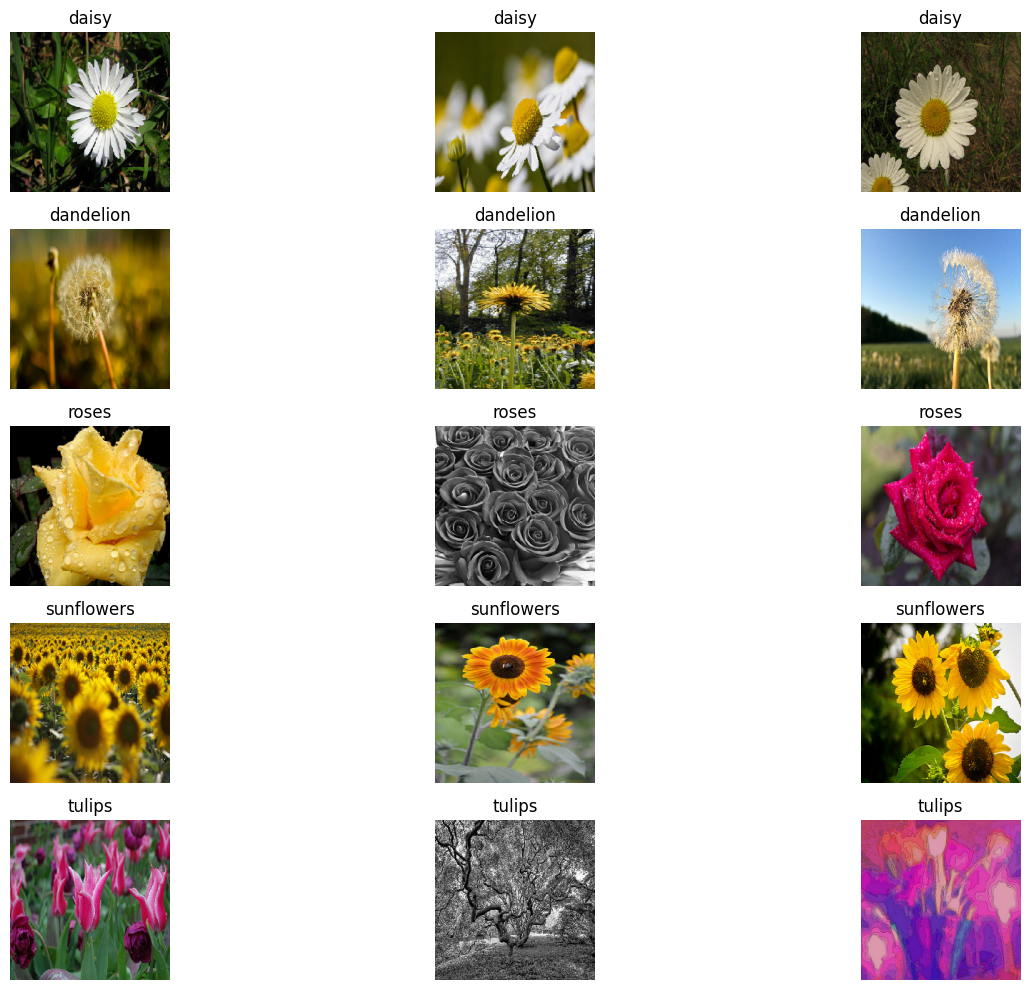

Sample images for each class displayed.


In [13]:
import matplotlib.pyplot as plt
import random

# Visualize sample images for each class
plt.figure(figsize=(15, 10))

sample_images_per_class = 3 # Number of sample images to display per class

for i, class_name in enumerate(class_names):
    class_path = correct_data_dir / class_name
    if class_path.is_dir():
        image_files = [f for f in class_path.iterdir() if f.is_file() and f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.gif']]

        # Select a few random sample images from the current class
        selected_samples = random.sample(image_files, min(len(image_files), sample_images_per_class))

        for j, img_path in enumerate(selected_samples):
            ax = plt.subplot(len(class_names), sample_images_per_class, i * sample_images_per_class + j + 1)
            img = tf.keras.utils.load_img(str(img_path), target_size=(IMG_HEIGHT, IMG_WIDTH))
            plt.imshow(img)
            plt.title(f"{class_name}")
            plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample images for each class displayed.")

## Crear Base de Datos y Tabla SQLite



In [14]:
import sqlite3

db_name = 'historial_consumo.db'
conn = None
try:
    # 1. Establish a connection to the SQLite database
    conn = sqlite3.connect(db_name)
    print(f"Database '{db_name}' opened successfully.")

    # 2. Create a cursor object
    cursor = conn.cursor()

    # 3. Execute a SQL query to create the table 'historial_consumo'
    create_table_sql = """
    CREATE TABLE IF NOT EXISTS historial_consumo (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        alimento TEXT,
        categoria TEXT,
        kcal INTEGER,
        fecha TEXT
    );
    """
    cursor.execute(create_table_sql)
    print("Table 'historial_consumo' created successfully or already exists.")

    # 4. Commit the changes to the database
    conn.commit()

except sqlite3.Error as e:
    print(f"SQLite error: {e}")
finally:
    # 5. Close the database connection
    if conn:
        conn.close()
        print(f"Database '{db_name}' connection closed.")

Database 'historial_consumo.db' opened successfully.
Table 'historial_consumo' created successfully or already exists.
Database 'historial_consumo.db' connection closed.


In [15]:
import sqlite3

db_name = 'registro_flores.db'
conn = None
try:
    # 1. Establish a connection to the SQLite database
    conn = sqlite3.connect(db_name)
    print(f"Database '{db_name}' opened successfully.")

    # 2. Create a cursor object
    cursor = conn.cursor()

    # 3. Execute a SQL query to create the table 'registro_flores'
    create_table_sql = """
    CREATE TABLE IF NOT EXISTS registro_flores (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        flor TEXT,
        tipo_flor TEXT,
        observaciones TEXT,
        fecha TEXT
    );
    """
    cursor.execute(create_table_sql)
    print("Table 'registro_flores' created successfully or already exists.")

    # 4. Commit the changes to the database
    conn.commit()

except sqlite3.Error as e:
    print(f"SQLite error: {e}")
finally:
    # 5. Close the database connection
    if conn:
        conn.close()
        print(f"Database '{db_name}' connection closed.")

Database 'registro_flores.db' opened successfully.
Table 'registro_flores' created successfully or already exists.
Database 'registro_flores.db' connection closed.


In [ ]:
from google.colab import files

files.download('registro_flores.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
from datetime import datetime

# 1. Get the current date and format it
current_date = datetime.now().strftime('%Y-%m-%d')

# 2. Define a default string for 'observaciones'
default_observaciones = 'Prediccion automatica del modelo'

# 3. Create a tuple containing the prediction data
# predicted_class_name is available from the kernel state
prediction_data = (
    predicted_class_name,    # flor
    predicted_class_name,    # tipo_flor
    default_observaciones,   # observaciones
    current_date             # fecha
)

print(f"Prepared prediction data for insertion: {prediction_data}")

Prepared prediction data for insertion: ('sunflowers', 'sunflowers', 'Prediccion automatica del modelo', '2026-01-04')


In [17]:
import sqlite3

db_name = 'registro_flores.db'
conn = None
try:
    # 1. Establish a connection to the SQLite database
    conn = sqlite3.connect(db_name)
    print(f"Database '{db_name}' opened successfully for insertion.")

    # 2. Create a cursor object
    cursor = conn.cursor()

    # 3. Define the SQL INSERT query for the 'registro_flores' table
    insert_sql = """
    INSERT INTO registro_flores (flor, tipo_flor, observaciones, fecha)
    VALUES (?, ?, ?, ?);
    """

    # prediction_data is available from the kernel state
    # 4. Execute the INSERT query using the prepared data
    cursor.execute(insert_sql, prediction_data)
    print(f"Prediction data inserted successfully: {prediction_data}")

    # 5. Commit the changes to the database
    conn.commit()

except sqlite3.Error as e:
    print(f"SQLite error during insertion: {e}")
finally:
    # 6. Close the database connection
    if conn:
        conn.close()
        print(f"Database '{db_name}' connection closed after insertion.")

Database 'registro_flores.db' opened successfully for insertion.
Prediction data inserted successfully: ('sunflowers', 'sunflowers', 'Prediccion automatica del modelo', '2026-01-04')
Database 'registro_flores.db' connection closed after insertion.


In [18]:
import sqlite3

db_name = 'registro_flores.db'
conn = None
try:
    # 1. Connect to the database
    conn = sqlite3.connect(db_name)
    print(f"Database '{db_name}' opened successfully for content verification.")

    # 2. Create a cursor object
    cursor = conn.cursor()

    # 3. Execute a SQL query to select all records from 'registro_flores'
    cursor.execute("SELECT * FROM registro_flores")

    # 4. Retrieve all results
    records = cursor.fetchall()

    # 5. Print the results
    print("\nCurrent content of 'registro_flores' table:")
    if records:
        # Print header
        column_names = [description[0] for description in cursor.description]
        print(column_names)
        for row in records:
            print(row)
    else:
        print("Table 'registro_flores' is empty.")

except sqlite3.Error as e:
    print(f"SQLite error during content verification: {e}")
finally:
    # 6. Close the database connection
    if conn:
        conn.close()
        print(f"Database '{db_name}' connection closed after verification.")

Database 'registro_flores.db' opened successfully for content verification.

Current content of 'registro_flores' table:
['id', 'flor', 'tipo_flor', 'observaciones', 'fecha']
(1, 'sunflowers', 'sunflowers', 'Prediccion automatica del modelo', '2026-01-04')
Database 'registro_flores.db' connection closed after verification.
